In [8]:
import pandas as pd
import plotly.express as px
from prophet import Prophet

In [ ]:
sales_data = pd.read_csv(r'test.csv')  
print(sales_data)

     trade_date  d_shop_sale  shop_cnt
0    2023-01-02     49116.19         1
1    2023-01-03     30395.55         1
2    2023-01-04     30905.16         1
3    2023-01-05     32081.14         1
4    2023-01-06     40312.58         1
..          ...          ...       ...
903  2025-06-25     26896.18         1
904  2025-06-26     28823.98         1
905  2025-06-27     29359.40         1
906  2025-06-28     48762.48         1
907  2025-06-29     44527.28         1

[908 rows x 3 columns]


In [10]:
sales_data['date'] = sales_data['trade_date']
data = sales_data.rename(columns = {"trade_date":"ds", "d_shop_sale":"y"})[["ds","y"]]
data['cap'] = 100000
print(data)

             ds         y     cap
0    2023-01-02  49116.19  100000
1    2023-01-03  30395.55  100000
2    2023-01-04  30905.16  100000
3    2023-01-05  32081.14  100000
4    2023-01-06  40312.58  100000
..          ...       ...     ...
903  2025-06-25  26896.18  100000
904  2025-06-26  28823.98  100000
905  2025-06-27  29359.40  100000
906  2025-06-28  48762.48  100000
907  2025-06-29  44527.28  100000

[908 rows x 3 columns]


In [11]:
fig = px.line(data, x="ds",y="y")
fig.show(renderer='browser')


In [12]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, growth='logistic')
model.add_country_holidays(country_name="CN")
model.fit(data)


01:34:12 - cmdstanpy - INFO - Chain [1] start processing
01:34:12 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = model.make_future_dataframe(periods=30)
future['cap'] = 100000
forecast = model.predict(future)

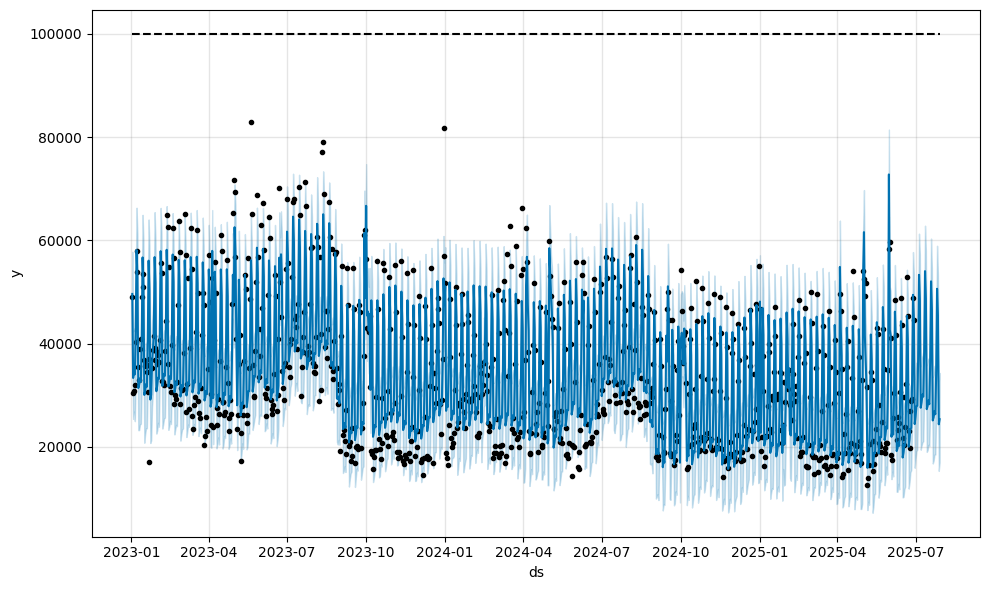

In [14]:
from prophet.plot import plot_plotly, plot_components_plotly
fig1 = model.plot(forecast)
fig1.savefig('temp1.png')

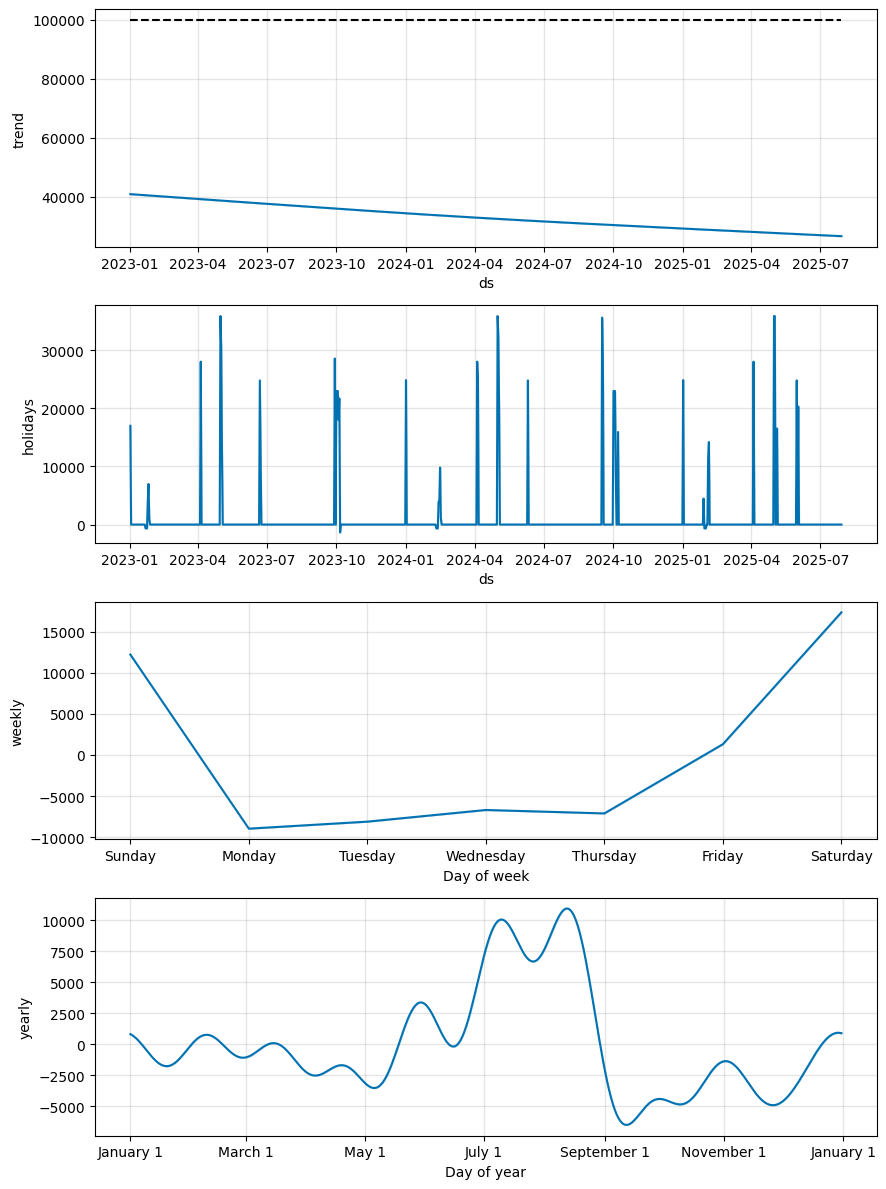

In [15]:
fig2 = model.plot_components(forecast)
fig2.savefig('temp2.png')